Object count after opening with minimum area 100: 5


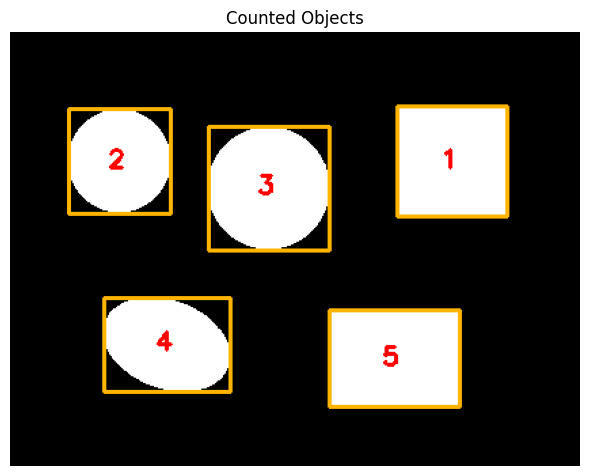

In [9]:
import cv2 # OpenCV library for computer vision tasks
import numpy as np # Numerical Python library for array operations
import matplotlib.pyplot as plt # Matplotlib for plotting and displaying images


def show_images(titles, images, cols=1, figsize=(6, 5)):
    """
    Displays a list of images with titles in a grid format using Matplotlib.

    Args:
        titles (list): List of strings, each being the title for an image.
        images (list): List of images (NumPy arrays) to be displayed.
        cols (int): Number of columns in the display grid. Default is 1.
        figsize (tuple): Figure size for matplotlib. Default is (6, 5).
    """
    # Create a figure with the specified size
    plt.figure(figsize=figsize)

    # Iterate through the titles and images to display each one
    for i, (title, image) in enumerate(zip(titles, images), start=1):
        # Create a subplot for the current image. The layout is 1 row, 'cols' columns.
        plt.subplot(1, cols, i)

        # Check if the image is color (3 channels) or grayscale (2 dimensions)
        if len(image.shape) == 3:
            # If it's a color image, convert BGR (OpenCV default) to RGB (Matplotlib default)
            plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        else:
            # If it's a grayscale image, display it with a 'gray' colormap
            plt.imshow(image, cmap="gray")

        # Set the title for the current subplot
        plt.title(title)
        # Turn off the axis ticks and labels
        plt.axis("off")

    # Adjust subplot parameters for a tight layout
    plt.tight_layout()
    # Display the plot
    plt.show()


def create_segmentation_sample():
    """
    Creates a deterministic sample grayscale image containing various shapes and noise.
    This image is suitable for testing segmentation and connected components analysis.

    Returns:
        numpy.ndarray: A grayscale image (uint8) with distinct shapes.
    """
    # Initialize a black image (background)
    image = np.zeros((320, 420), dtype=np.uint8)

    # Draw various shapes onto the image with different intensity values
    cv2.circle(image, (80, 95), 38, 210, -1) # Circle 1
    cv2.circle(image, (190, 115), 45, 230, -1) # Circle 2
    cv2.rectangle(image, (285, 55), (365, 135), 200, -1) # Rectangle 1
    cv2.ellipse(image, (115, 230), (48, 32), 20, 0, 360, 220, -1) # Ellipse
    cv2.rectangle(image, (235, 205), (330, 275), 235, -1) # Rectangle 2

    # Add random noise (sparse white pixels) to the image
    rng = np.random.default_rng(11) # Seed for reproducibility

    for _ in range(60):
        row = rng.integers(0, image.shape[0])
        col = rng.integers(0, image.shape[1])
        image[row, col] = 255 # Set random pixel to white

    return image


# --- Main Image Processing Pipeline ---

# 1. Create Sample Image
# Generate a grayscale image with various shapes for segmentation demonstration.
segmentation_img = create_segmentation_sample()

# 2. Thresholding
# Convert the grayscale image into a binary image. Pixels above a certain threshold
# become white (255), and others become black (0).
# cv2.THRESH_OTSU automatically determines the optimal threshold value.
_, binary_img = cv2.threshold(
    segmentation_img, # Input image
    0,                # Lower bound for threshold (ignored with THRESH_OTSU)
    255,              # Max value to use for output if pixel value > threshold
    cv2.THRESH_BINARY + cv2.THRESH_OTSU # Type of thresholding (binary + Otsu's method)
)

# 3. Morphological Opening
# Opening is an erosion followed by a dilation. It helps remove small objects (noise)
# and separates objects that are connected by a thin bridge, without significantly
# changing the size of larger objects.

# Define a structuring element (kernel) for the morphological operation.
# cv2.MORPH_ELLIPSE creates an elliptical shape, often good for circular/oval objects.
kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE, # Shape of the kernel (ellipse)
    (5, 5)             # Size of the kernel (5x5 pixels)
)

# Apply the morphological opening operation
opened_img = cv2.morphologyEx(
    binary_img,    # Input binary image
    cv2.MORPH_OPEN, # Type of morphological operation (opening)
    kernel         # Structuring element
)

# 4. Connected Components Analysis
# This function labels connected regions in the binary image. It returns:
# - num_labels: Total number of labeled components (including background).
# - labels: An image where each pixel's value is the label of the component it belongs to.
# - stats: Statistics for each label, including bounding box, area, etc.
# - centroids: Centroid (x, y) coordinates for each label.
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    opened_img,   # Input binary image
    connectivity=8 # 8-connectivity (pixels are connected if they touch horizontally, vertically, or diagonally)
)

# 5. Object Filtering and Visualization
min_area = 100 # Minimum area threshold to consider an object valid
object_count = 0 # Counter for valid objects

# Convert the opened binary image to a 3-channel BGR image for drawing color annotations.
count_visualization = cv2.cvtColor(
    opened_img,
    cv2.COLOR_GRAY2BGR
)

# Iterate through each detected component (label), skipping the background (label_id 0).
for label_id in range(1, num_labels):

    # Get the area of the current component.
    area = stats[label_id, cv2.CC_STAT_AREA]

    # Filter out components smaller than the minimum area.
    if area < min_area:
        continue

    # Increment the object counter for valid objects.
    object_count += 1

    # Extract bounding box coordinates (top-left x, top-left y, width, height)
    x = stats[label_id, cv2.CC_STAT_LEFT]
    y = stats[label_id, cv2.CC_STAT_TOP]
    w = stats[label_id, cv2.CC_STAT_WIDTH]
    h = stats[label_id, cv2.CC_STAT_HEIGHT]

    # Get the centroid coordinates.
    cx, cy = centroids[label_id]

    # Draw a rectangle around the detected object.
    cv2.rectangle(
        count_visualization,       # Image to draw on
        (x, y),                    # Top-left corner of the rectangle
        (x + w, y + h),            # Bottom-right corner of the rectangle
        (0, 180, 255),             # Color of the rectangle (BGR: yellow-orange)
        2                          # Thickness of the rectangle line
    )

    # Put the object count number near the centroid of the object.
    cv2.putText(
        count_visualization,       # Image to draw on
        str(object_count),         # Text to draw (current object number)
        (int(cx) - 8, int(cy) + 5),# Position of the text (slightly offset from centroid)
        cv2.FONT_HERSHEY_SIMPLEX,  # Font type
        0.6,                       # Font scale
        (0, 0, 255),               # Color of the text (BGR: red)
        2                          # Thickness of the text line
    )

# 6. Print Results and Display Visualization
print(f"Object count after opening with minimum area {min_area}: {object_count}")

# Display the final image with counted objects and bounding boxes.
show_images(
    ["Counted Objects"],
    [count_visualization],
    cols=1,
    figsize=(6, 5)
)